data_x.shape:  torch.Size([1, 48, 2])
data_y.shape:  torch.Size([1, 48, 1])


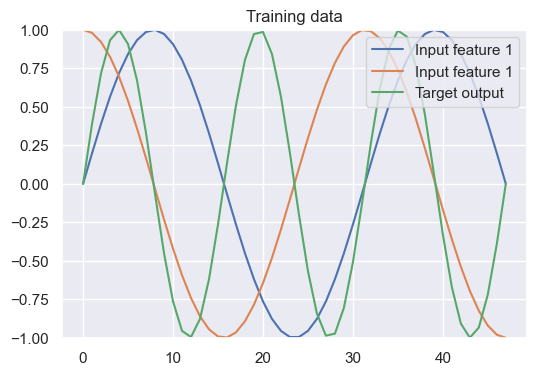

In [4]:
# %%
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from ncps.wirings import FullyConnected, Random, NCP
from ncps.torch import LTC
import matplotlib.pyplot as plt
import seaborn as sns

# %% [markdown]
# ## Generating synthetic sinusoidal training data

# %%
N = 48  # Length of the time-series
# Input feature is a sine and a cosine wave
data_x = np.stack(
    [np.sin(np.linspace(0, 3 * np.pi, N)), np.cos(np.linspace(0, 3 * np.pi, N))], axis=1
)
data_x = np.expand_dims(data_x, axis=0).astype(np.float32)  # Add batch dimension
# Target output is a sine with double the frequency of the input signal
data_y = np.sin(np.linspace(0, 6 * np.pi, N)).reshape([1, N, 1]).astype(np.float32)

# Convert to PyTorch Tensors
data_x = torch.tensor(data_x)
data_y = torch.tensor(data_y)

print("data_x.shape: ", str(data_x.shape))
print("data_y.shape: ", str(data_y.shape))

# Let's visualize the training data
sns.set()
plt.figure(figsize=(6, 4))
plt.plot(data_x[0, :, 0], label="Input feature 1")
plt.plot(data_x[0, :, 1], label="Input feature 1")
plt.plot(data_y[0, :, 0], label="Target output")
plt.ylim((-1, 1))
plt.title("Training data")
plt.legend(loc="upper right")
plt.show()

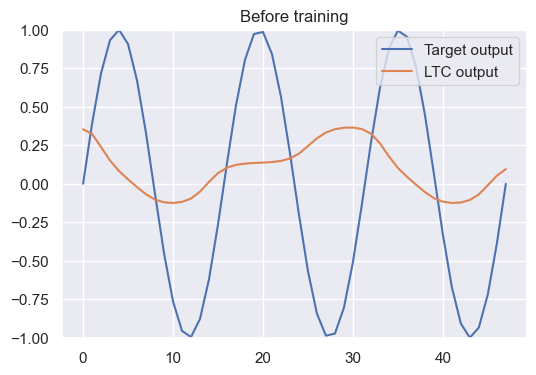

Epoch 0: Loss 0.48847
Epoch 50: Loss 0.10547
Epoch 100: Loss 0.00900
Epoch 150: Loss 0.00332
Epoch 200: Loss 0.00153
Epoch 250: Loss 0.00234
Epoch 300: Loss 0.00088
Epoch 350: Loss 0.00063


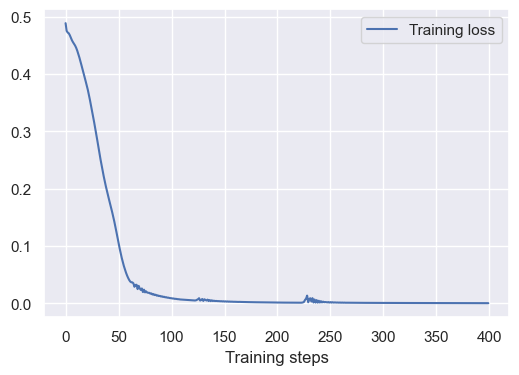

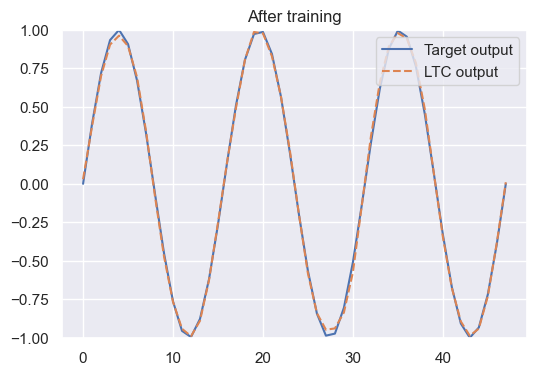

In [ ]:
# %% [markdown]
# ### Our first LTC model with fully-connected wiring

# %%
# Define the wiring
fc_wiring = FullyConnected(units=8, output_dim=1)

# Define the model
# input_size=2 because we have sine and cosine features
fc_model = LTC(input_size=2, units=fc_wiring, batch_first=True)


# Define a generic training function to reuse later
def train_model(model, x, y, epochs=400, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        # Forward pass
        output, _ = model(x)
        loss = criterion(output, y)
        # Backward pass
        loss.backward()
        optimizer.step()

        history.append(loss.item())
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Loss {loss.item():.5f}")

    return history, output


# %% [markdown]
# ### Visualizing the prediction of the network before training

# %%
sns.set()
with torch.no_grad():
    prediction, _ = fc_model(data_x)

plt.figure(figsize=(6, 4))
plt.plot(data_y[0, :, 0], label="Target output")
plt.plot(prediction[0, :, 0], label="LTC output")
plt.ylim((-1, 1))
plt.title("Before training")
plt.legend(loc="upper right")
plt.show()

# %% [markdown]
# ### Training the model

# %%
hist_fc, _ = train_model(fc_model, data_x, data_y, epochs=400)

# %% [markdown]
# ### Plotting the training loss

# %%
sns.set()
plt.figure(figsize=(6, 4))
plt.plot(hist_fc, label="Training loss")
plt.legend(loc="upper right")
plt.xlabel("Training steps")
plt.show()

# %% [markdown]
# ### Plotting the prediction of the trained model

# %%
with torch.no_grad():
    prediction, _ = fc_model(data_x)

plt.figure(figsize=(6, 4))
plt.plot(data_y[0, :, 0], label="Target output")
plt.plot(prediction[0, :, 0], label="LTC output", linestyle="dashed")
plt.ylim((-1, 1))
plt.legend(loc="upper right")
plt.title("After training")
plt.show()

Epoch 0: Loss 0.52373
Epoch 50: Loss 0.48760
Epoch 100: Loss 0.47674
Epoch 150: Loss 0.40085
Epoch 200: Loss 0.38071
Epoch 250: Loss 0.37607
Epoch 300: Loss 0.37238
Epoch 350: Loss 0.36874


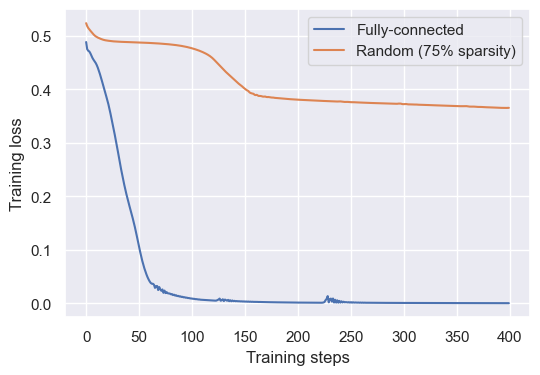

In [7]:
# %% [markdown]
# ### Random network with 75% sparsity

# %%
# Define wiring
rnd_wiring = Random(units=8, output_dim=1, sparsity_level=0.75)

# Define model
sparse_model = LTC(input_size=2, units=rnd_wiring, batch_first=True)

# %% [markdown]
# ### Comparing random sparse vs fully-connected networks

# %%
hist_rand, _ = train_model(sparse_model, data_x, data_y, epochs=400)

sns.set()
plt.figure(figsize=(6, 4))
plt.plot(hist_fc, label="Fully-connected")
plt.plot(hist_rand, label="Random (75% sparsity)")
plt.legend(loc="upper right")
plt.xlabel("Training steps")
plt.ylabel("Training loss")
plt.show()

Epoch 0: Loss 0.55885
Epoch 50: Loss 0.04155
Epoch 100: Loss 0.00893
Epoch 150: Loss 0.00630
Epoch 200: Loss 0.00318
Epoch 250: Loss 0.00229
Epoch 300: Loss 0.00144
Epoch 350: Loss 0.00119


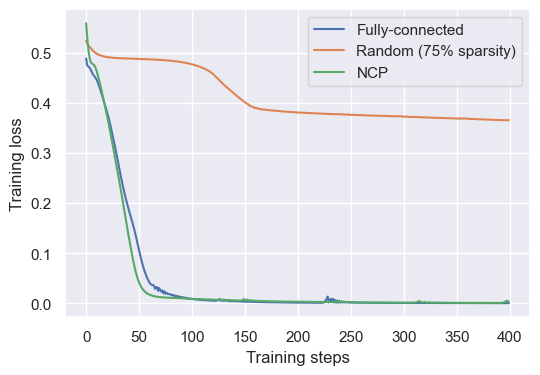

Sparsity level is 79.69%


In [8]:
# %% [markdown]
# ### Neural Circuit Policy wiring architecture

# %%
ncp_wiring = NCP(
    inter_neurons=3,
    command_neurons=4,
    motor_neurons=1,
    sensory_fanout=2,
    inter_fanout=2,
    recurrent_command_synapses=3,
    motor_fanin=4,
)

ncp_model = LTC(input_size=2, units=ncp_wiring, batch_first=True)

# Train the NCP model
hist_ncp, _ = train_model(ncp_model, data_x, data_y, epochs=400)

sns.set()
plt.figure(figsize=(6, 4))
plt.plot(hist_fc, label="Fully-connected")
plt.plot(hist_rand, label="Random (75% sparsity)")
plt.plot(hist_ncp, label="NCP")
plt.legend(loc="upper right")
plt.xlabel("Training steps")
plt.ylabel("Training loss")
plt.show()

# %% [markdown]
# ### Computing the sparsity of a NCP network

# %%
# Sparsity calculation
fc_synapses = fc_wiring.synapse_count
ncp_synapses = ncp_wiring.synapse_count

sparsity = 1 - ncp_synapses / fc_synapses
print("Sparsity level is {:0.2f}%".format(100 * sparsity))

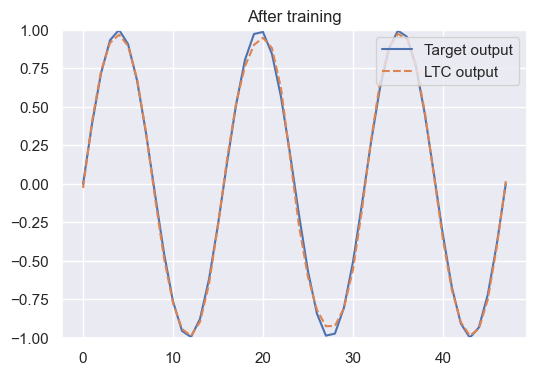

In [ ]:
with torch.no_grad():
    prediction, _ = ncp_model(data_x)

plt.figure(figsize=(6, 4))
plt.plot(data_y[0, :, 0], label="Target output")
plt.plot(prediction[0, :, 0], label="LTC output", linestyle="dashed")
plt.ylim((-1, 1))
plt.legend(loc="upper right")
plt.title("After training")
plt.show()